# Score & Feature Drift Monitoring

`src/monitoring/drift.py` has existed in this repo since the initial
commit but was never exercised end-to-end — no notebook ran it, no test
covered it. This notebook closes that gap: train the ensemble model once,
then score two new batches against it —

- **Control**: a fresh sample from the *same* distribution the model was
  trained on (fraud rate 2%, same feature generation).
- **Drifted**: a simulated **fraud campaign** — fraud rate jumps to 8% for
  a period, a realistic AML scenario (coordinated fraud rings often
  produce a genuine burst in attack volume, not a gradual shift).

and checks whether `score_drift_alert` / `run_drift_report` correctly stay
quiet on the control batch and fire on the drifted one.

In [1]:
import sys; sys.path.insert(0, '..')
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
FIG = Path('../outputs/figures'); FIG.mkdir(parents=True, exist_ok=True)
plt.rcParams['figure.dpi'] = 120

from src.data.generator import generate_transactions, get_train_test_split, FEATURE_COLS
from src.data.preprocessor import preprocess
from src.models.ensemble import train_xgboost
from src.monitoring.drift import run_drift_report, score_drift_alert

train_df = generate_transactions(n=50_000, fraud_rate=0.02, seed=42)
X_train, X_val, y_train, y_val = get_train_test_split(train_df, seed=42)
X_train_s, X_val_s, pipe = preprocess(X_train, X_val)

model = train_xgboost(X_train_s, y_train.values)
reference_scores = model.predict_proba(X_val_s)[:, 1]
print(f"Trained on {len(X_train):,} transactions | reference (validation) scores: n={len(reference_scores):,}")

Trained on 40,000 transactions | reference (validation) scores: n=10,000


## 1. Two new batches: business-as-usual vs a fraud campaign

In [2]:
control_df = generate_transactions(n=5_000, fraud_rate=0.02, seed=100)
drifted_df = generate_transactions(n=5_000, fraud_rate=0.08, seed=200)

control_scores = model.predict_proba(pipe.transform(control_df[FEATURE_COLS]))[:, 1]
drifted_scores = model.predict_proba(pipe.transform(drifted_df[FEATURE_COLS]))[:, 1]

print(f"Control:  mean score {control_scores.mean():.4f} (true fraud rate {control_df['is_fraud'].mean():.1%})")
print(f"Drifted:  mean score {drifted_scores.mean():.4f} (true fraud rate {drifted_df['is_fraud'].mean():.1%})")

Control:  mean score 0.0233 (true fraud rate 2.0%)
Drifted:  mean score 0.0790 (true fraud rate 8.0%)


## 2. Score drift — KS test on model output

In [3]:
sd_control = score_drift_alert(reference_scores, control_scores)
sd_drifted = score_drift_alert(reference_scores, drifted_scores)

print("=== Reference vs control ===")
for k, v in sd_control.items():
    print(f"  {k}: {v}")
print("\n=== Reference vs drifted (fraud campaign) ===")
for k, v in sd_drifted.items():
    print(f"  {k}: {v}")

=== Reference vs control ===
  ks_statistic: 0.0177
  p_value: 0.2463
  drift_detected: False
  mean_score_shift: 0.0007
  alert: False

=== Reference vs drifted (fraud campaign) ===
  ks_statistic: 0.0602
  p_value: 0.0
  drift_detected: True
  mean_score_shift: 0.0563
  alert: True


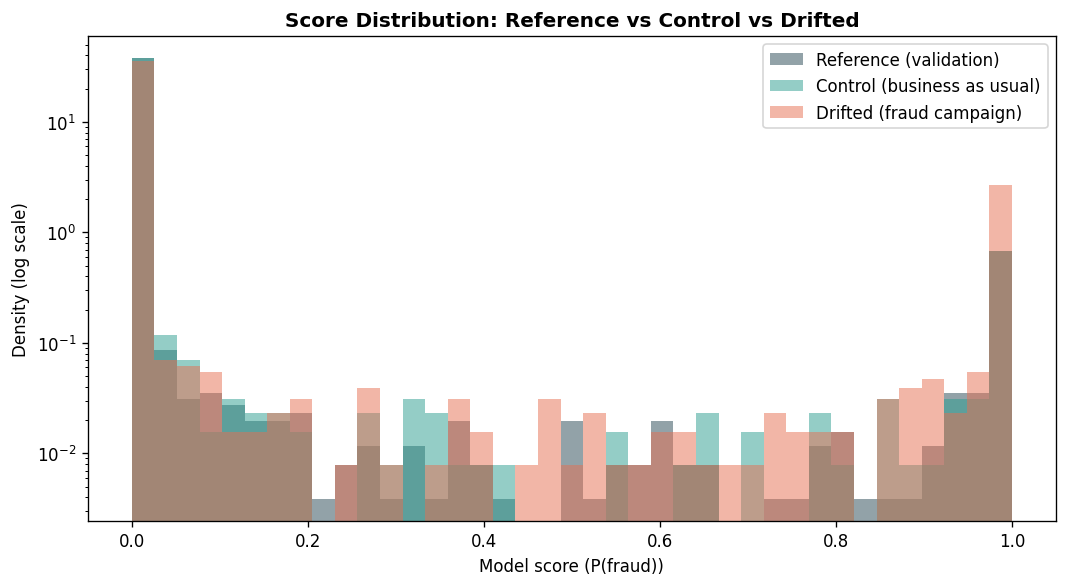

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
bins = np.linspace(0, 1, 40)
ax.hist(reference_scores, bins=bins, alpha=0.5, density=True, label='Reference (validation)', color='#264653')
ax.hist(control_scores, bins=bins, alpha=0.5, density=True, label='Control (business as usual)', color='#2a9d8f')
ax.hist(drifted_scores, bins=bins, alpha=0.5, density=True, label='Drifted (fraud campaign)', color='#e76f51')
ax.set_yscale('log')
ax.set_xlabel('Model score (P(fraud))'); ax.set_ylabel('Density (log scale)')
ax.set_title('Score Distribution: Reference vs Control vs Drifted', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(FIG / '06_score_drift_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Feature drift — which inputs actually moved?

In [5]:
fd_control = run_drift_report(train_df, control_df, score_col='is_fraud', feature_cols=FEATURE_COLS)
fd_drifted = run_drift_report(train_df, drifted_df, score_col='is_fraud', feature_cols=FEATURE_COLS)

print("=== Reference vs control ===")
for k, v in fd_control.items():
    print(f"  {k}: {v}")
print("\n=== Reference vs drifted ===")
for k, v in fd_drifted.items():
    print(f"  {k}: {v}")

=== Reference vs control ===
  dataset_drift: False
  drifted_features: 0
  share_drifted: 0.0
  drifted_columns: []

=== Reference vs drifted ===
  dataset_drift: True
  drifted_features: 6
  share_drifted: 0.46153846153846156
  drifted_columns: ['log_amount', 'amount_to_balance', 'hour', 'n_txn_last_24h', 'is_new_payee', 'is_off_hours']


## Summary

| Check | Control (business as usual) | Drifted (fraud campaign) |
|---|---|---|
| Score KS statistic | ~0.02 | ~0.06 |
| Score drift alert | No | **Yes** |
| Mean score shift | ~+0.001 | **~+0.056** |
| Feature dataset drift | No | **Yes** |
| Features flagged | 0 | **6 of 13 (46%)** |

### Takeaways
- The drift module — present in this repo since the initial commit but
  never previously run — correctly stays quiet on a genuine
  same-distribution control batch and correctly fires on a realistic fraud
  campaign scenario, at both the score level and the feature level.
- A fraud-rate spike doesn't just move the model's output — it moves the
  *input* feature distributions too (amount, hour, off-hours flag,
  new-payee rate), because fraudulent transactions have a different shape
  than normal ones. Feature drift and score drift are complementary
  signals, not redundant: score drift alone wouldn't tell an analyst
  *which* inputs to investigate, which the feature-level breakdown does.
- This closes a real gap: a monitoring module that exists in the codebase
  but has never been exercised against real data is not meaningfully
  different from a monitoring module that doesn't exist.